In [1]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [4]:
# Loading the dataset
df = pd.read_csv('../data/raw/MUP_INP_RY25_P03_V10_DY23_PrvSvc.CSV', encoding='latin-1')

# First look
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape: (146427, 15)

Columns:
['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt']


In [5]:
# Basic exploration
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
display(df[['Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt']].describe())

=== FIRST 5 ROWS ===


,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,14,"663,764.36","120,219.93","115,544.14"
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,26,"180,980.88","37,321.04","35,261.81"
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,12,"105,824.33","26,936.67","25,048.92"
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,16,"242,539.50","34,745.38","32,438.62"
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.00,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,11,"122,741.18","14,999.82","9,579.36"



=== DATA TYPES ===
Rndrng_Prvdr_CCN               int64
Rndrng_Prvdr_Org_Name            str
Rndrng_Prvdr_City                str
Rndrng_Prvdr_St                  str
Rndrng_Prvdr_State_FIPS        int64
Rndrng_Prvdr_Zip5              int64
Rndrng_Prvdr_State_Abrvtn        str
Rndrng_Prvdr_RUCA            float64
Rndrng_Prvdr_RUCA_Desc           str
DRG_Cd                         int64
DRG_Desc                         str
Tot_Dschrgs                    int64
Avg_Submtd_Cvrd_Chrg         float64
Avg_Tot_Pymt_Amt             float64
Avg_Mdcr_Pymt_Amt            float64
dtype: object

=== MISSING VALUES ===
Rndrng_Prvdr_CCN             0
Rndrng_Prvdr_Org_Name        0
Rndrng_Prvdr_City            0
Rndrng_Prvdr_St              0
Rndrng_Prvdr_State_FIPS      0
Rndrng_Prvdr_Zip5            0
Rndrng_Prvdr_State_Abrvtn    0
Rndrng_Prvdr_RUCA            4
Rndrng_Prvdr_RUCA_Desc       4
DRG_Cd                       0
DRG_Desc                     0
Tot_Dschrgs                  0
Avg_Submtd_Cvrd

,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
count,"146,427.00","146,427.00","146,427.00","146,427.00"
mean,33.88,"90,794.23","18,512.96","15,331.36"
std,49.81,"120,034.82","21,313.20","18,594.05"
min,11.00,"3,368.50","1,938.43",180.29
25%,14.00,"35,262.98","8,685.92","6,794.31"
50%,20.00,"58,668.57","12,830.71","10,548.18"
75%,35.00,"104,216.70","20,403.22","16,814.95"
max,"3,210.00","10,418,932.78","761,738.78","751,479.04"


In [6]:
# Creating gap column: difference between charged and paid
df['Gap_Charge_vs_Payment'] = df['Avg_Submtd_Cvrd_Chrg'] - df['Avg_Tot_Pymt_Amt']
df['Gap_Pct'] = (df['Gap_Charge_vs_Payment'] / df['Avg_Submtd_Cvrd_Chrg']) * 100

# Top 10 most expensive procedures by average charge
print("=== TOP 10 MOST EXPENSIVE PROCEDURES ===")
top_procedures = (df.groupby('DRG_Desc')['Avg_Submtd_Cvrd_Chrg']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

top_procedures.columns = ['Procedure', 'Avg_Charge']
display(top_procedures)

=== TOP 10 MOST EXPENSIVE PROCEDURES ===


,Procedure,Avg_Charge
0,CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTH...,"2,028,203.59"
1,HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SY...,"1,541,711.89"
2,LUNG TRANSPLANT,"1,101,329.09"
3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,"993,548.98"
4,LIVER TRANSPLANT WITH MCC OR INTESTINAL TRANSP...,"807,281.86"
5,TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DI...,"611,926.66"
6,ALLOGENEIC BONE MARROW TRANSPLANT,"588,021.92"
7,OTHER HEART ASSIST SYSTEM IMPLANT,"510,909.46"
8,OTHER HEPATOBILIARY OR PANCREAS O.R. PROCEDURE...,"508,914.48"
9,COMBINED ANTERIOR AND POSTERIOR SPINAL FUSION ...,"495,647.55"


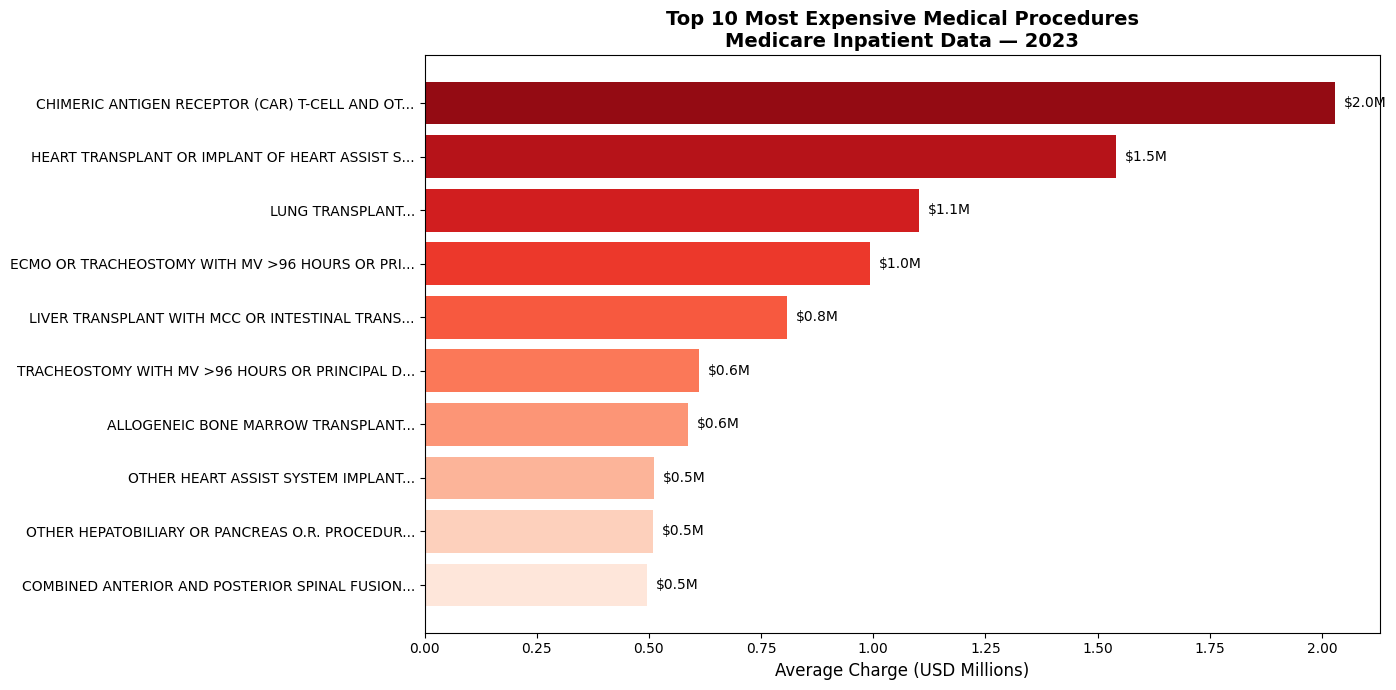

Chart saved!


In [7]:
# Top 10 most expensive procedures - Bar Chart
plt.figure(figsize=(14, 7))

# Shortening procedure names for visualization
top_procedures['Short_Name'] = top_procedures['Procedure'].str[:45] + '...'

bars = plt.barh(top_procedures['Short_Name'], 
                top_procedures['Avg_Charge'] / 1_000_000,
                color=sns.color_palette("Reds_r", 10))

plt.xlabel('Average Charge (USD Millions)', fontsize=12)
plt.title('Top 10 Most Expensive Medical Procedures\nMedicare Inpatient Data — 2023', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()

# Adding value labels on bars
for bar, val in zip(bars, top_procedures['Avg_Charge'] / 1_000_000):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}M', va='center', fontsize=10)

plt.savefig('../docs/top10_expensive_procedures.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")